# 01 - Exploratory Data Analysis

Project: Finnish NHL Players: A Zone-Level Shooting Efficiency Analysis

## Purpose 
Explore the combined shot dataset to understand its structure and key distributions
before moving to formal analysis. This notebook identifies patterns, checks assumptions,
and guides the analytical decisions made in subsequent notebooks.
  
## Input
- data/processed/shots_combined.csv

## Questions explored
1. How are shots distributed across nationalities?
2. How are shots distributed across ice zones?
3. How do Finnish players compare to the NHL population in basic shooting metrics?
4. Are there any unexpected patterns or data quality issues?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DATA = Path('../data/processed')
dataframe = pd.read_csv(PROCESSED_DATA / 'shots_combined.csv')

print(f"Dataset loaded: {len(dataframe)} rows, {dataframe.shape[1]} columns")

Dataset loaded: 338141 rows, 126 columns


# 02 - Dataset Overview

In [2]:
print("Seasons:")
print(dataframe['season'].value_counts().sort_index())

print("Key columns:")
key_columns = ['shooterName', 'nationality', 'xGoal', 'goal', 'arenaAdjustedXCord', 'arenaAdjustedYCord', 'shotType', 'season']
print(dataframe[key_columns].head(10))

Seasons:
season
2022    113138
2023    113785
2024    111218
Name: count, dtype: int64
Key columns:
           shooterName nationality     xGoal  goal  arenaAdjustedXCord  \
0           Timo Meier         CHE  0.026009     0                47.0   
1  Marc-Edouard Vlasic         CAN  0.007774     0                45.0   
2       Mattias Ekholm         SWE  0.046070     0               -31.0   
3      Kiefer Sherwood         USA  0.296800     1               -76.0   
4       Colton Sissons         CAN  0.057435     0               -82.0   
5         Yakov Trenin         RUS  0.060461     0               -71.0   
6       Steven Lorentz         CAN  0.084009     0                75.0   
7  Marc-Edouard Vlasic         CAN  0.061371     0                54.0   
8         Dante Fabbro         CAN  0.025160     0               -39.0   
9       Oskar Lindblom         SWE  0.029708     0                52.0   

   arenaAdjustedYCord shotType  season  
0                 8.0    WRIST    2022  
1  

# 03 - Nationality distribution

In [3]:
nationality_counts = dataframe['nationality'].value_counts()

print(nationality_counts.head(10))
print(f"Total nationalities in dataset: {dataframe['nationality'].nunique()}")
print(f"Finnish shots: {nationality_counts.get('FIN')}")
print(f"Finnish share of all shots: {nationality_counts.get('FIN') / len(dataframe) * 100:.2f}%")

nationality
CAN    137597
USA    101189
SWE     33319
RUS     20601
FIN     15461
CZE      8801
CHE      7148
DEU      3914
SVK      2284
DNK      2277
Name: count, dtype: int64
Total nationalities in dataset: 22
Finnish shots: 15461
Finnish share of all shots: 4.57%


### Shot volume distribution by nationality (top 10)

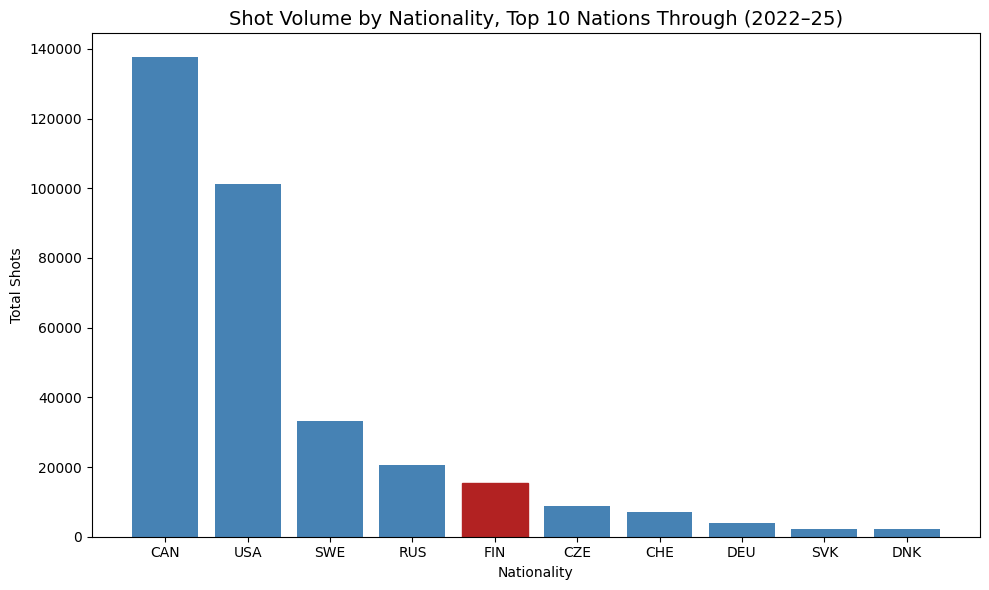

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

top10 = nationality_counts.head(10)
bars = ax.bar(top10.index, top10.values, color='steelblue')

fin_index = list(top10.index).index('FIN')
bars[fin_index].set_color('firebrick')

ax.set_title('Shot Volume by Nationality, Top 10 Nations Through (2022–25)', fontsize=14)
ax.set_xlabel('Nationality')
ax.set_ylabel('Total Shots')

plt.tight_layout()
plt.savefig('../visualizations/01_shot_volume_by_nationality.png', dpi=150)
plt.show()

### Shooting efficiency on national level (goals vs. xG)

In [5]:
efficiency = dataframe.groupby('nationality').agg(
    shots=('xGoal', 'count'),
    goals=('goal', 'sum'),
    xG=('xGoal', 'sum')
).reset_index()

efficiency['goals_minus_xG'] = efficiency['goals'] - efficiency['xG']
efficiency['relative_efficiency'] = efficiency['goals_minus_xG'] / efficiency['xG']

efficiency = efficiency[efficiency['shots'] >= 10000]
efficiency = efficiency.sort_values('relative_efficiency', ascending=False)

print(efficiency.to_string(index=False))

nationality  shots  goals           xG  goals_minus_xG  relative_efficiency
        RUS  20601   1600  1508.180958       91.819042             0.060881
        SWE  33319   2260  2271.493196      -11.493196            -0.005060
        FIN  15461   1162  1168.948233       -6.948233            -0.005944
        CAN 137597   9782 10096.858372     -314.858372            -0.031184
        USA 101189   6923  7190.128786     -267.128786            -0.037152


### National level visualization

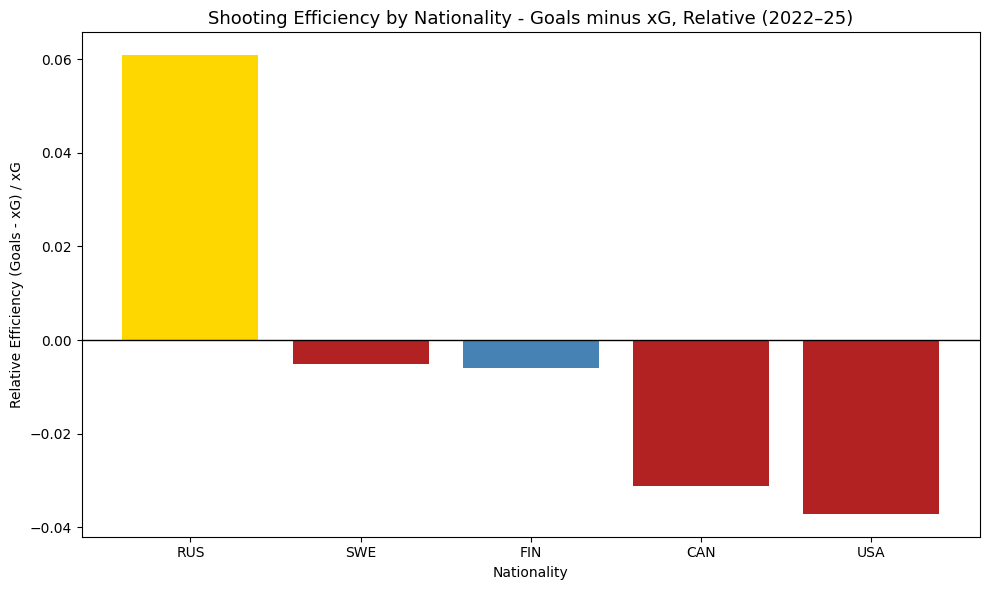

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['firebrick' if i < 0 else 'gold' for i in efficiency['relative_efficiency']]
final_color = ['steelblue' if n == 'FIN' else c for n, c in zip(efficiency['nationality'], colors)]
bars = ax.bar(efficiency['nationality'], efficiency['relative_efficiency'], color = final_color)

ax.axhline(y=0, c='black', lw=1, ls='-')
ax.set_title('Shooting Efficiency by Nationality - Goals minus xG, Relative (2022–25)', fontsize=13)
ax.set_xlabel('Nationality')
ax.set_ylabel('Relative Efficiency (Goals - xG) / xG')

plt.tight_layout()
plt.savefig('../visualizations/02_shooting_efficiency_by_nationality.png', dpi=150)
plt.show()

# 04 - Exploring shot coordinate distribution and classifying shooting zones

In [7]:
print(dataframe['arenaAdjustedXCordABS'].describe())
print()
print(dataframe['arenaAdjustedYCordAbs'].describe())
print()
print(f"Shots with xABS >= 89: {(dataframe['arenaAdjustedXCordABS'] >= 89).sum()}")
print(f"Shots with xABS >= 69: {(dataframe['arenaAdjustedXCordABS'] >= 69).sum()}")
print(f"Shots with xABS >= 54: {(dataframe['arenaAdjustedXCordABS'] >= 54).sum()}")
print(f"Shots with xABS < 54: {(dataframe['arenaAdjustedXCordABS'] < 54).sum()}")

# Y-coordinate max value seemed off compared to research (NHL rink y-cordABS should be max 42.5) , doing a similar check on the sums as for X-coordinates.
print()

print(f"Shots with yABS <= 43: {(dataframe['arenaAdjustedYCordAbs'] <= 42.5).sum()}")
print(f"Shots with yABS > 43: {(dataframe['arenaAdjustedYCordAbs'] > 42.5).sum()}")
print(f"Shots with yABS > 45:   {(dataframe['arenaAdjustedYCordAbs'] > 45).sum()}")
print(f"Shots with yABS > 50:   {(dataframe['arenaAdjustedYCordAbs'] > 50).sum()}")
print(f"Shots with yABS >= 54:  {(dataframe['arenaAdjustedYCordAbs'] >= 54).sum()}")

count    338141.000000
mean         61.122857
std          19.416121
min           0.000000
25%          48.000000
50%          64.000000
75%          78.000000
max         100.000000
Name: arenaAdjustedXCordABS, dtype: float64

count    338141.000000
mean         16.621161
std          11.880228
min           0.000000
25%           6.000000
50%          15.000000
75%          26.000000
max          55.000000
Name: arenaAdjustedYCordAbs, dtype: float64

Shots with xABS >= 89: 4960
Shots with xABS >= 69: 142046
Shots with xABS >= 54: 228430
Shots with xABS < 54: 109711

Shots with yABS <= 43: 336255
Shots with yABS > 43: 1886
Shots with yABS > 45:   275
Shots with yABS > 50:   20
Shots with yABS >= 54:  2


### Note on coordinate choice

Both "yCord" and "arenaAdjustedYCord" were examined. The raw yCord stays
within the official NHL range of +-43, while arenaAdjustedYCordAbs produces
1886 values (0.56%) outside this range which seems to be a side effect of MoneyPuck's
arena-adjusted coordinates.

Despite this, we use arena-adjusted coordinates ("arenaAdjustedXCordABS" and
"arenaAdjustedYCordAbs") for zone classification for two reasons:

1. Arena adjustment corrects for systematic recording biases that vary across
   NHL arenas and without it, shot locations are not directly comparable between
   arenas.
2. The out-of-range values represent 0.56% of all shots and have no meaningful
   impact on group-level findings.

This choice is a known limitation and is documented in the project README.

### Zone Classification

Shots are classified into three zones based on arena-adjusted coordinates:

- Blue line shots: xABS 25–41, any y (shots from near the blue line)
- Slot: xABS ≥ 76, yABS ≤ 10 (high-danger area directly in front of the net)
- Arc + other: xABS 41–89, yABS > 10 (mid-range shots, excluding slot and blue line)
- Shots with xABS < 25 (neutral/defensive zone) and xABS > 89 (behind goal line) are excluded from zone analysis.

Zone boundaries:
- Blue line: x = 25
- Goal line: x = 89
- Slot depth: 13 feet from goal line (x = 76)
- Slot width: ±10 feet from center (y = ±10)

In [8]:
def classify_zone(x_abs, y_abs):
    if x_abs < 25 or x_abs > 89:
        return 'excluded'
    elif x_abs <= 41:
        return 'blue_line'
    elif x_abs >= 76 and y_abs <= 10:
        return 'slot'
    else:
        return 'arc'

dataframe['zone'] = dataframe.apply(
    lambda row: classify_zone(
        row['arenaAdjustedXCordABS'],
        row['arenaAdjustedYCordAbs']
    ),
    axis=1
)

zone_counts = dataframe['zone'].value_counts()
print(zone_counts)
print(f"\nAs percentage of all shots:")
print((zone_counts / len(dataframe) * 100).round(1))

zone
arc          207618
slot          61663
blue_line     53377
excluded      15483
Name: count, dtype: int64

As percentage of all shots:
zone
arc          61.4
slot         18.2
blue_line    15.8
excluded      4.6
Name: count, dtype: float64


C:\Users\juuso\AppData\Local\Temp\ipykernel_26796\1706021435.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['zone'] = dataframe.apply(


# 05 - Zone-level shooting efficiency by nationality

Does shooting efficiency (goals - xG) vary by zone across nationalities?

In [9]:
zone_min_shots = 1000

zone_efficiency = dataframe[dataframe['zone'] != 'excluded'].groupby(
    ['nationality', 'zone']
).agg(
    shots=('xGoal', 'count'),
    goals=('goal', 'sum'),
    xG=('xGoal', 'sum')
).reset_index()

zone_efficiency['goals_minus_xG'] = zone_efficiency['goals'] - zone_efficiency['xG']
zone_efficiency['relative_efficiency'] = zone_efficiency['goals_minus_xG'] / zone_efficiency['xG']

# Apply minimum threshold per zone separately
zone_efficiency = zone_efficiency[zone_efficiency['shots'] >= zone_min_shots]

for zone in ['slot', 'blue_line', 'arc']:
    print(f"{zone.upper()}")
    zone_data = zone_efficiency[zone_efficiency['zone'] == zone].sort_values(
        'relative_efficiency', ascending=False
    )
    print(zone_data[['nationality', 'shots', 'goals', 'xG', 'relative_efficiency']].to_string(index=False))

SLOT
nationality  shots  goals          xG  relative_efficiency
        FIN   2752    416  483.679220            -0.139926
        RUS   3561    527  614.951412            -0.143022
        CAN  25831   3674 4571.793011            -0.196377
        USA  18618   2591 3230.977330            -0.198075
        CHE   1481    210  263.305801            -0.202448
        CZE   1647    225  284.402272            -0.208867
        SWE   5322    718  937.330598            -0.233995
BLUE_LINE
nationality  shots  goals         xG  relative_efficiency
        RUS   2955     92  74.819183             0.229631
        CZE   1264     36  31.543958             0.141265
        CAN  22749    507 521.405967            -0.027629
        SWE   5980    139 143.666467            -0.032481
        USA  16028    312 350.552735            -0.109977
        FIN   1992     41  56.489289            -0.274199
ARC
nationality  shots  goals          xG  relative_efficiency
        DNK   1681    117   95.919775       

### Zone efficiency by nationality vizualized

NHL average efficiency per zone:
zone
arc          0.128055
blue_line   -0.043681
slot        -0.195008
Name: nhl_avg_efficiency, dtype: float64



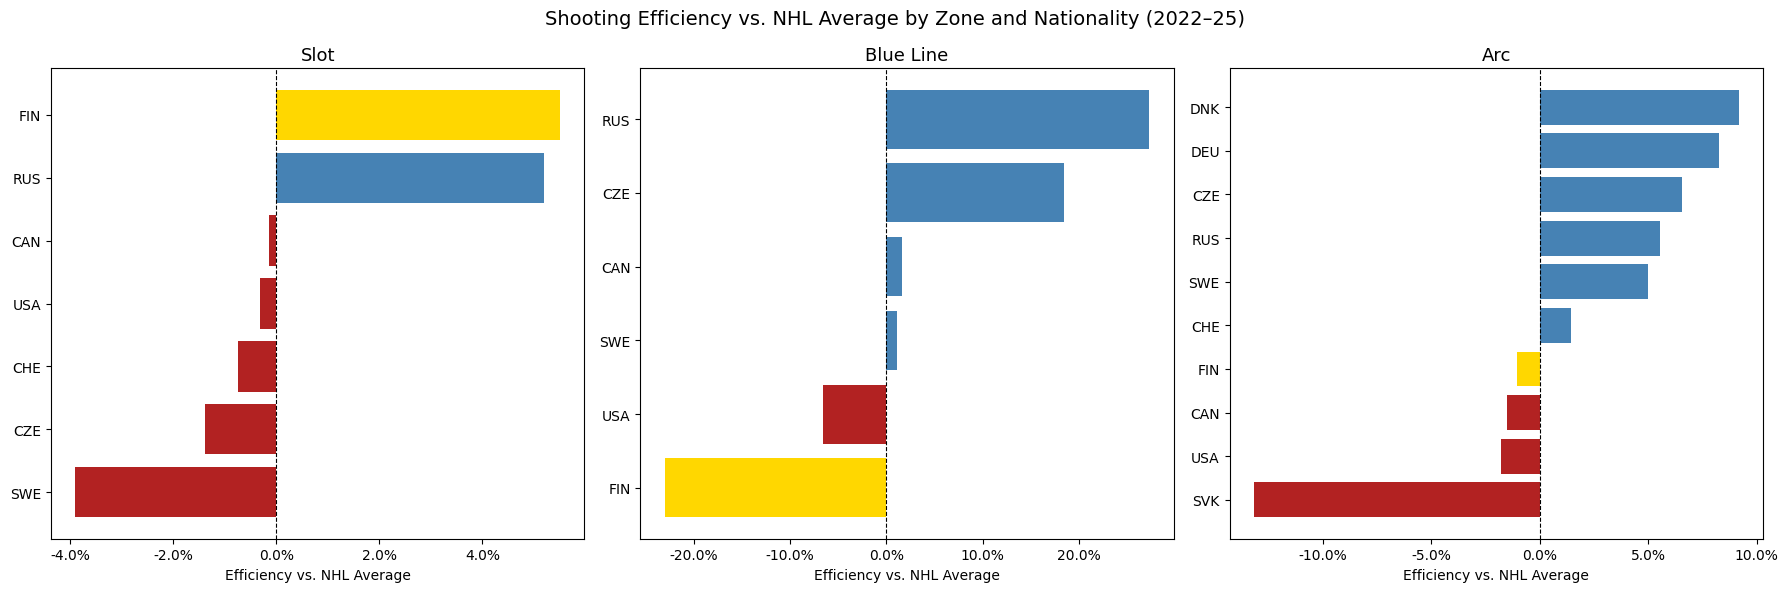

Chart saved.


In [10]:
zones = ['slot', 'blue_line', 'arc']
zone_labels = {'slot': 'Slot', 'blue_line': 'Blue Line', 'arc': 'Arc'}

# Normalize to NHL average per zone
nhl_avg = zone_efficiency.groupby('zone').apply(
    lambda x: (x['goals'].sum() - x['xG'].sum()) / x['xG'].sum()
).rename('nhl_avg_efficiency')

zone_efficiency = zone_efficiency.merge(nhl_avg, on='zone')
zone_efficiency['efficiency_vs_nhl'] = (
    zone_efficiency['relative_efficiency'] - zone_efficiency['nhl_avg_efficiency']
)

print("NHL average efficiency per zone:")
print(nhl_avg)
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, zone in enumerate(zones):
    ax = axes[i]
    zone_data = zone_efficiency[zone_efficiency['zone'] == zone].sort_values(
        'efficiency_vs_nhl', ascending=True
    )
    
    colors = ['gold' if n == 'FIN' else 
              'firebrick' if x < 0 else 
              'steelblue' 
              for n, x in zip(zone_data['nationality'], zone_data['efficiency_vs_nhl'])]
    
    ax.barh(zone_data['nationality'], zone_data['efficiency_vs_nhl'], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(zone_labels[zone], fontsize=13)
    ax.set_xlabel('Efficiency vs. NHL Average')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.suptitle('Shooting Efficiency vs. NHL Average by Zone and Nationality (2022–25)', fontsize=14)
plt.tight_layout()
plt.savefig('../visualizations/03_zone_efficiency_by_nationality.png', dpi=150)
plt.show()
print("Chart saved.")

# Summary

This notebook explored the combined shot dataset to understand distributions 
and identify patterns before formal statistical analysis.

### Key Findings

Nationality distribution:
- Dataset contains 22 nationalities across 338,141 shots (2022–25 regular season)
- Canadian players account for the largest share, Finnish players are 5th with around 4.6% of all shots

Overall shooting efficiency:
- Russian players outperform xG most significantly (+6.1% vs. NHL average)
- Finnish and Swedish players are close to NHL average overall
- Canadian and American players underperform xG slightly

Zone-level efficiency vs. NHL average:
- Finnish players are the strongest nationality from the slot (+5% vs. NHL average)
- Finnish players are the weakest nationality from the blue line (-23% vs. NHL average)
- Finnish players are slightly below NHL average from everywhere else in the offensive zone

### Key Analytical Decisions Made in This Notebook
1. Nationality threshold set to 1,000 shots per zone which ensures reliable group-level estimates
2. Zone boundaries defined using arenaAdjustedXCordABS and arenaAdjustedYCordAbs
3. Efficiency normalized to NHL average per zone which eliminates systematic xG model bias
4. Left/right side of ice treated as equivalent (absolute y-values used)

### Next Steps
Formal statistical analysis in 03_zone_analysis.ipynb:
- Bootstrapped confidence intervals per nationality per zone
- Statistical significance testing of observed differences
- Publication-ready visualizations